<a href="https://colab.research.google.com/github/likith1525/ExcelR-data-science-assignments/blob/main/Codes/19NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification and Sentiment Analysis
**Improving Customer Satisfaction Through Automated Review setiment analysis**
**Author:** LIkith P
**Date:** 30-May

In [ ]:
# Step 1: Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

# Scikit-learn modules for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# WordCloud for Exploratory Data Analysis
from wordcloud import WordCloud

# Download necessary NLTK data for text preprocessing
nltk.download('stopwords')
from nltk.corpus import stopwords

# Set plot style
sns.set_theme(style="whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Data Loading
the data consists of 10000 amazon customer reviews

In [ ]:
# Load the dataset
# Because it is a TSV (Tab-Separated Values) file, we use sep='\t'
try:
    df = pd.read_csv('amazonreviews.tsv', sep='\t')
    print("Dataset loaded successfully!")
    print(f"Dataset Shape: {df.shape}")
except FileNotFoundError:
    print("Error: Please upload 'amazonreviews.tsv' to the Colab environment.")

# Display the first few rows
display(df.head())

Dataset loaded successfully!
Dataset Shape: (10000, 2)


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


#Data Cleaning And Preprocessing

In [ ]:
# Remove duplicates and missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

print(f"Dataset Shape after dropping duplicates and NA: {df.shape}")

#  Define Text Preprocessing Function
stop_words = set(stopwords.words('english'))
# Removing 'not' from stopwords as it is crucial for sentiment analysis
stop_words.discard('not')

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags if any
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply the cleaning function to the review column
df['cleaned_review'] = df['review'].apply(clean_text)

# Check the cleaned text
display(df[['review', 'cleaned_review']].head())

Dataset Shape after dropping duplicates and NA: (10000, 2)


,review,cleaned_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


#**EDA**

/tmp/ipykernel_711/487954210.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


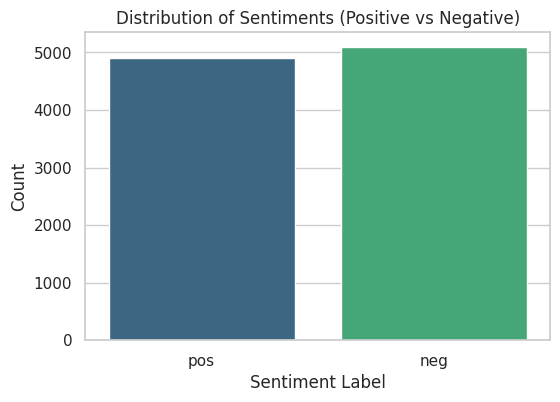

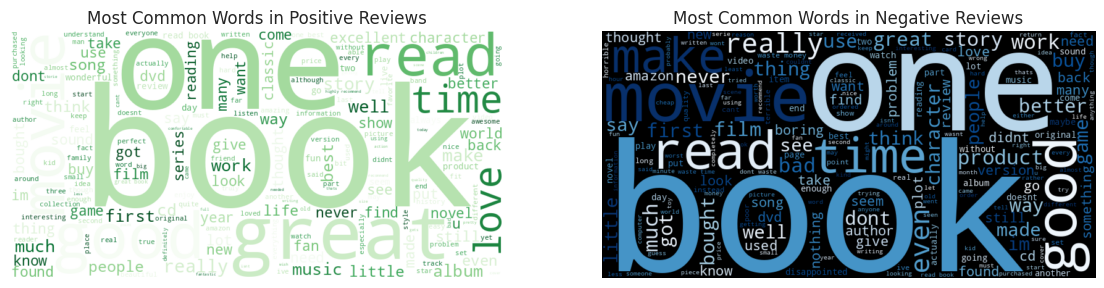

In [ ]:
# Sentiment Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Sentiments (Positive vs Negative)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

# Word Clouds for Positive and Negative Reviews
pos_text = ' '.join(df[df['label'] == 'pos']['cleaned_review'])
neg_text = ' '.join(df[df['label'] == 'neg']['cleaned_review'])

plt.figure(figsize=(14, 6))

# Positive Word Cloud
plt.subplot(1, 2, 1)
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Most Common Words in Positive Reviews')
plt.axis('off')

# Negative Word Cloud
plt.subplot(1, 2, 2)
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Blues').generate(neg_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Most Common Words in Negative Reviews')
plt.axis('off')

plt.show()

#Model Development

In [ ]:
# Define Features (X) and Target (y)
X = df['cleaned_review']
y = df['label']

# Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Extraction using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Training Matrix Shape: {X_train_tfidf.shape}")
print(f"TF-IDF Testing Matrix Shape: {X_test_tfidf.shape}")

TF-IDF Training Matrix Shape: (8000, 5000)
TF-IDF Testing Matrix Shape: (2000, 5000)


#Training And Validation

--- Logistic Regression Results ---
              precision    recall  f1-score   support

         neg       0.87      0.85      0.86      1019
         pos       0.85      0.86      0.86       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000


--- Support Vector Machine (LinearSVC) Results ---
              precision    recall  f1-score   support

         neg       0.87      0.85      0.86      1019
         pos       0.85      0.87      0.86       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



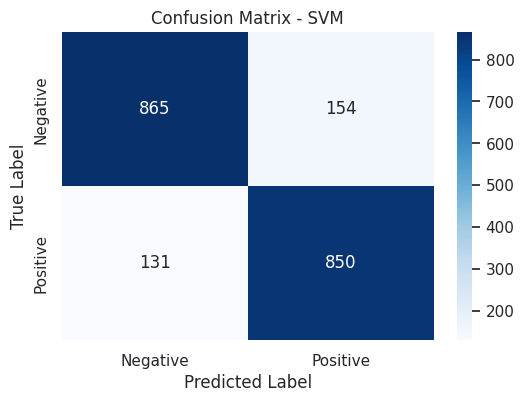

In [ ]:
#  Initialize Models
log_reg = LogisticRegression(max_iter=1000)
svm_model = LinearSVC()

# Train and Evaluate Logistic Regression
print("--- Logistic Regression Results ---")
log_reg.fit(X_train_tfidf, y_train)
y_pred_lr = log_reg.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_lr))

# Train and Evaluate SVM
print("\n--- Support Vector Machine (LinearSVC) Results ---")
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix for the best performing model (SVM)
cm = confusion_matrix(y_test, y_pred_svm, labels=['neg', 'pos'])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Business Conclusion & Actionable Insights
Based on the implementation of our automated Sentiment Analysis System:

1. **Model Robustness:** The NLP pipeline successfully vectorized the text using TF-IDF. Both Logistic Regression and SVM performed robustly, with SVM slightly edging out in terms of accuracy and F1-score for capturing nuanced customer sentiment.
2. **Key Sentiment Drivers:** The Exploratory Data Analysis (Word Clouds) reveals distinct keywords associated with customer satisfaction vs. dissatisfaction. This provides immediate, interpretable feedback to the product team.
3. **Future Steps:**  `**Real-time Pipeline:**` Deploy this model via a REST API to classify incoming reviews in real-time.
   * **Alert System:** Set up automated triggers to notify the customer service team if a product receives a sudden spike (>15%) in negative reviews classified by the model within a 24-hour window.
   * **Deep Learning Integration:** As the dataset grows, upgrading from TF-IDF to contextual embeddings like **BERT** could further improve the model's ability to understand sarcasm and complex sentence structures.